In [ ]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Configuration
WINDOW_SIZE   = 30
FUTURE_N      = 10

BUY_THRESH    = 0.03
SELL_THRESH   = -0.03

N_SPLITS      = 5

EPOCHS_CV     = 5
EPOCHS_FINAL  = 30

BATCH_SIZE    = 128

FEATURES      = ['Open', 'High', 'Low', 'Close', 'Volume']
NUM_FEATURES  = len(FEATURES)

In [ ]:
# Load & Preprocess Data
data = pd.read_csv('CII-VNINDEX-History.csv')
data.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Sort time
data['TradingDate'] = pd.to_datetime(data['TradingDate'])
data = data.sort_values('TradingDate').reset_index(drop=True)

print(f"Total rows: {len(data)}") # >= 120

df = data[FEATURES].copy()
close = data['Close'].values

Total rows: 4186


In [ ]:
# Create Labels using Future Return Threshold

def make_windows_and_labels(df, close, window_size, future_n, buy_thresh, sell_thresh, mode='buy'):
    # Buy label: future_return > BUY_THRESH
    # Sell label: future_return < SELL_THRESH
    # Hold: Skip
    X_list, y_list, idx_list = [], [], []

    for i in range(len(df) - window_size - future_n):
        future_return = (close[i + window_size + future_n - 1]- close[i + window_size - 1]) / close[i + window_size - 1]
        if mode == 'buy':
            if future_return > buy_thresh:
                label = 1
            elif future_return < sell_thresh:
                label = 0
            else:
                continue
        else:
            if future_return < sell_thresh:
                label = 1
            elif future_return > buy_thresh:
                label = 0
            else:
                continue

        window = df.iloc[i : i + window_size].values

        X_list.append(window)
        y_list.append(label)
        idx_list.append(i)

    return np.array(X_list), np.array(y_list), idx_list

In [ ]:
# Build CNN Model

def build_model(window_size, num_features):
    model = Sequential([
        Conv1D(64, 3,
            activation='relu',
            padding='same',
            input_shape=(window_size, num_features),
            kernel_regularizer=tf.keras.regularizers.l2(0.001)
        ),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),
        Conv1D(128, 3,
            activation='relu',
            padding='same',
            kernel_regularizer=tf.keras.regularizers.l2(0.001)
        ),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),
        Flatten(),
        Dense(64,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(0.001)
        ),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )

    return model

In [ ]:
# Time-Series Train / Validation / Test Split
def time_series_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

    print("Train:", X_train.shape)
    print("Val:", X_val.shape)
    print("Test:", X_test.shape)

    return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
# Normalize Data
def normalize(X_train, X_val, X_test, num_features):
    scaler = MinMaxScaler()
    X_train_norm = scaler.fit_transform(X_train.reshape(-1, num_features)).reshape(X_train.shape)

    X_val_norm = scaler.transform(X_val.reshape(-1, num_features)).reshape(X_val.shape)

    X_test_norm = scaler.transform(X_test.reshape(-1, num_features)).reshape(X_test.shape)

    return X_train_norm, X_val_norm, X_test_norm, scaler

In [ ]:
# Time-Series Cross Validation
def run_cv(X_train, y_train, window_size, num_features, n_splits=5, epochs=5, batch_size=64):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_accs = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):

        X_tr, X_val_cv = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val_cv = y_train[tr_idx], y_train[val_idx]

        scaler_fold = MinMaxScaler()

        X_tr_n = scaler_fold.fit_transform(X_tr.reshape(-1, num_features)).reshape(X_tr.shape)
        X_val_n = scaler_fold.transform(X_val_cv.reshape(-1, num_features)).reshape(X_val_cv.shape)

        classes = np.unique(y_tr)

        cw = compute_class_weight('balanced', classes=classes,y=y_tr)

        cw_dict = dict(zip(classes, cw))

        model_cv = build_model(window_size, num_features)

        model_cv.fit(X_tr_n, y_tr,
            validation_data=(X_val_n, y_val_cv),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=cw_dict,
            verbose=0
        )

        y_prob = model_cv.predict(X_val_n, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        acc = accuracy_score(y_val_cv, y_pred)
        cv_accs.append(acc)
        print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    print(
        f"Mean Accuracy: "
        f"{np.mean(cv_accs):.4f} ± {np.std(cv_accs):.4f}"
    )

    return cv_accs

In [ ]:
# Evaluation
def evaluate_model(model, X_test_norm, y_test, label_name, threshold=0.5):
    y_prob = model.predict(X_test_norm, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)
    print(f"{label_name} Signal — Evaluation")
    print(classification_report(y_test, y_pred, target_names=['No Signal', 'Signal']))
    fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Signal', 'Signal'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{label_name} — Confusion Matrix')
    return y_prob

In [ ]:
# Plot Buy / Sell Signals on Price

def plot_signals_on_price(close, indices, y_pred, y_prob, label_name, window_size, color_signal, color_no):
    signal_dates = [idx + window_size for idx in indices]

    plt.figure(figsize=(16, 6), dpi=150)
    plt.plot(close, color='#333', lw=1, label='Close Price', alpha=0.7)

    sig_idx = [signal_dates[i] for i in range(len(y_pred))if y_pred[i] == 1]
    nosig_idx = [signal_dates[i] for i in range(len(y_pred)) if y_pred[i] == 0]

    plt.scatter(sig_idx, close[sig_idx], color=color_signal, s=40, zorder=5, label=f'{label_name} Signal', alpha=0.8)
    plt.scatter(nosig_idx, close[nosig_idx], color=color_no, s=10, zorder=4, label='No Signal', alpha=0.3)

    plt.title(f'{label_name} Signals on Close Price')
    plt.xlabel('Day index')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Task 3.1 — Buy Signal Identification**

In [ ]:
# Create Buy Labels
X_buy, y_buy, idx_buy = make_windows_and_labels(df, close, WINDOW_SIZE, FUTURE_N, BUY_THRESH, SELL_THRESH, mode='buy')
print(f"Total samples (Buy task): {len(X_buy)}")

print(
    f"Buy=1: {y_buy.sum()} "
    f"| Buy=0: {(y_buy==0).sum()}"
)

print(f"Class ratio: {y_buy.mean():.2%}")

Total samples (Buy task): 2683
Buy=1: 1387 | Buy=0: 1296
Class ratio: 51.70%


In [ ]:
# Train / Validation / Test Split (Buy)
X_tr_b, X_val_b, X_te_b, y_tr_b, y_val_b, y_te_b = (time_series_split(X_buy, y_buy))

Train: (1716, 30, 5)
Val: (430, 30, 5)
Test: (537, 30, 5)


In [ ]:
# Normalize Data (Buy)
X_tr_bn, X_val_bn, X_te_bn, _ = normalize(X_tr_b, X_val_b, X_te_b, NUM_FEATURES)

In [ ]:
# Cross Validation (Buy)
cv_buy = run_cv(X_tr_b, y_tr_b, WINDOW_SIZE, NUM_FEATURES, N_SPLITS, EPOCHS_CV, BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy: 0.6189


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Accuracy: 0.5490


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Accuracy: 0.5769


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Accuracy: 0.6049


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Accuracy: 0.3601
Mean Accuracy: 0.5420 ± 0.0940


In [ ]:
# Train Final Buy Model
cw_buy = compute_class_weight('balanced', classes=np.unique(y_tr_b), y=y_tr_b)

cw_buy_dict = dict(zip(np.unique(y_tr_b), cw_buy))

model_buy = build_model(WINDOW_SIZE, NUM_FEATURES)

es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_buy = model_buy.fit(
    X_tr_bn,
    y_tr_b,
    validation_data=(X_val_bn, y_val_b),
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    class_weight=cw_buy_dict,
    callbacks=[es]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 1.1321 - precision_17: 0.5810 - recall_17: 0.4809 - val_loss: 0.9032 - val_precision_17: 0.4054 - val_recall_17: 0.5172
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.9987 - precision_17: 0.6149 - recall_17: 0.5894 - val_loss: 0.9073 - val_precision_17: 0.3893 - val_recall_17: 0.8391
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.9412 - precision_17: 0.6288 - recall_17: 0.5766 - val_loss: 0.8961 - val_precision_17: 0.4101 - val_recall_17: 0.5115
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.8980 - precision_17: 0.6283 - recall_17: 0.5521 - val_loss: 0.8924 - val_precision_17: 0.4383 - val_recall_17: 0.4080
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.8763 - precision_17: 0.6461 - recall_17: 0.6447 - val_loss: 0.8866 - val_precision_17: 0.6552 - val_recall_17: 0.2184
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.8758 - precision_17: 0.6460 - recall_17: 0.5

Buy Signal Signal — Evaluation
              precision    recall  f1-score   support

   No Signal       0.78      0.19      0.30       264
      Signal       0.55      0.95      0.69       273

    accuracy                           0.58       537
   macro avg       0.66      0.57      0.50       537
weighted avg       0.66      0.58      0.50       537



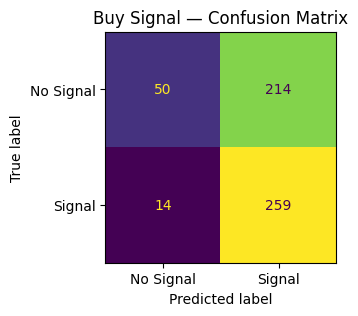

In [ ]:
# Evaluate Buy Model
y_prob_buy = evaluate_model(model_buy, X_te_bn, y_te_b, "Buy Signal")

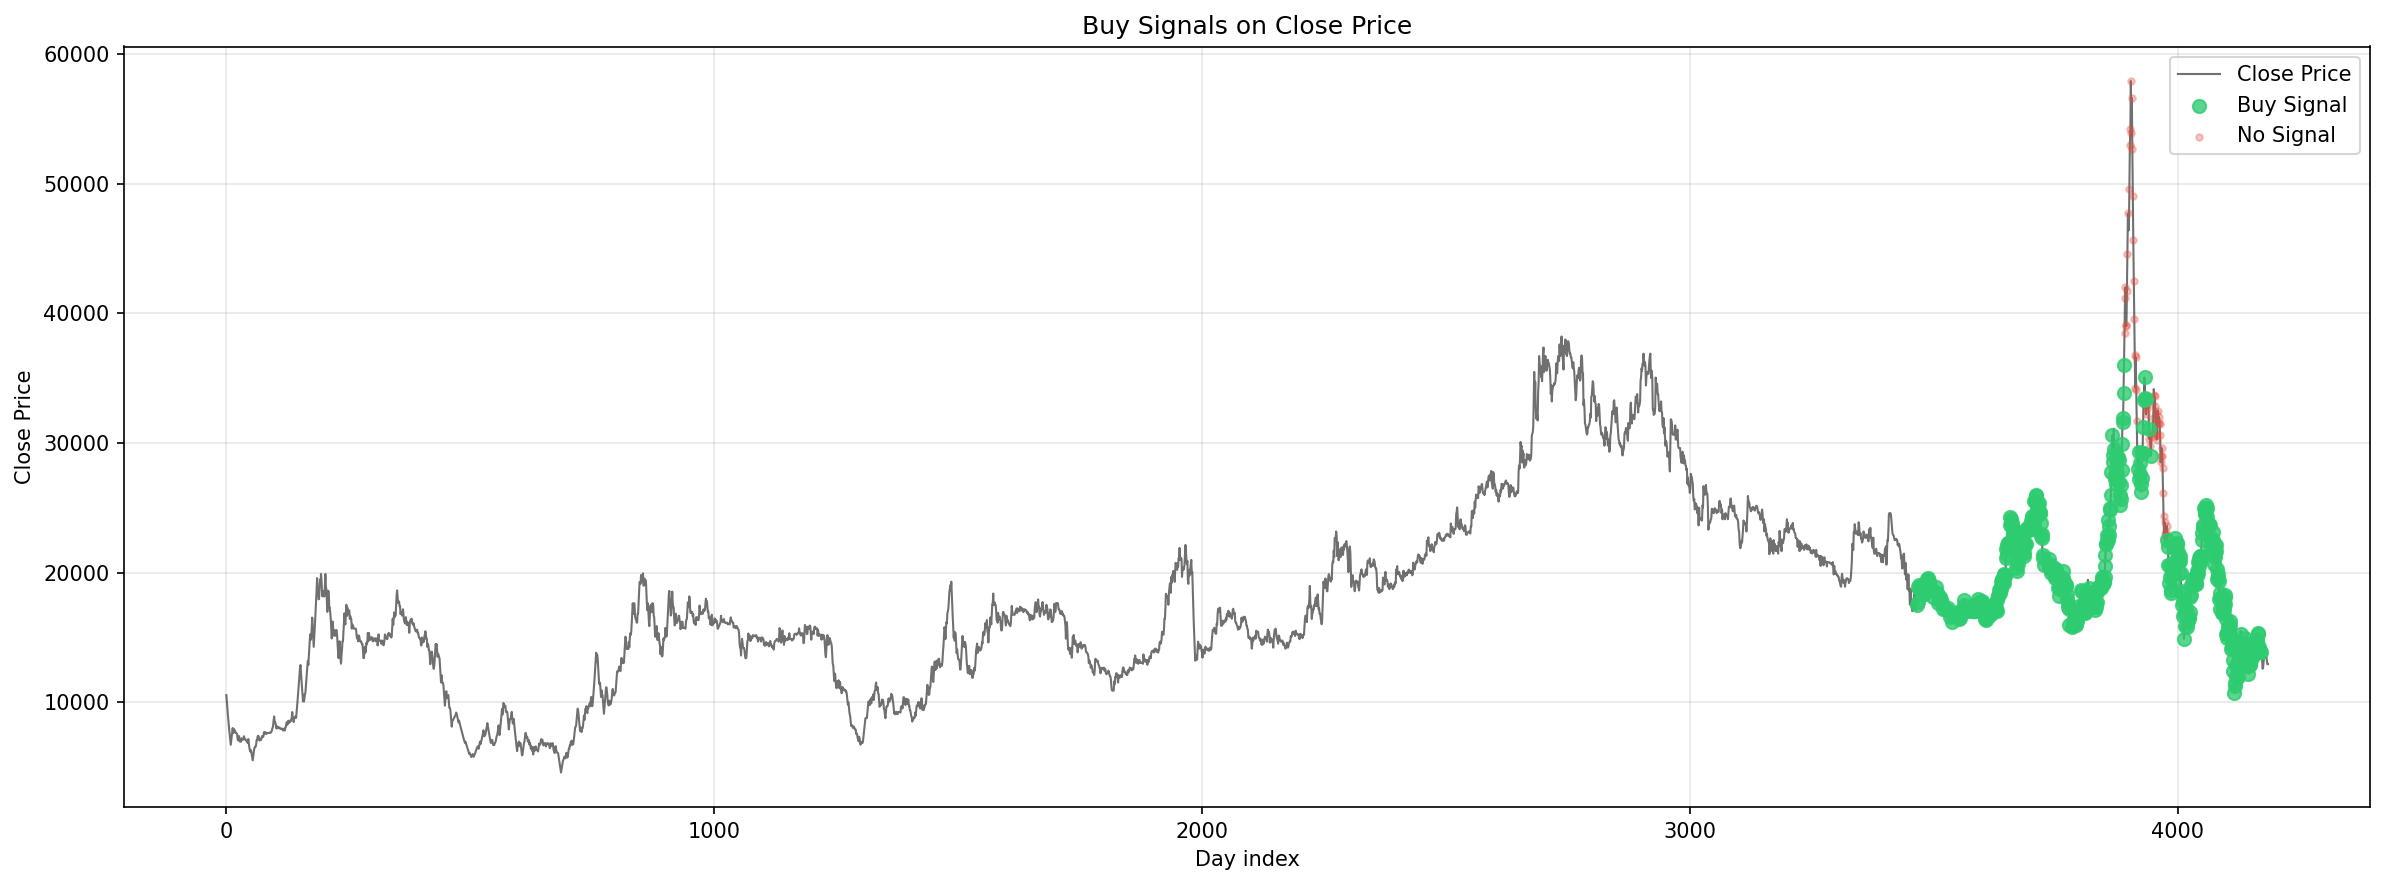

In [ ]:
# Plot Buy Signals
y_pred_buy = (y_prob_buy >= 0.5).astype(int)
test_indices = idx_buy[-len(y_pred_buy):]
plot_signals_on_price(
    close,
    test_indices,
    y_pred_buy,
    y_prob_buy,
    "Buy",
    WINDOW_SIZE,
    color_signal='#2ecc71',
    color_no='#e74c3c'
)

**Task 3.2 — Sell Signal Identification**

In [ ]:
# Create Sell Labels
X_sell, y_sell, idx_sell = make_windows_and_labels(df, close, WINDOW_SIZE, FUTURE_N, BUY_THRESH, SELL_THRESH, mode='sell')

print(f"Total samples (Sell task): {len(X_sell)}")

print(
    f"Sell=1: {y_sell.sum()} "
    f"| Sell=0: {(y_sell==0).sum()}"
)

print(f"Class ratio: {y_sell.mean():.2%}")

Total samples (Sell task): 2683
Sell=1: 1296 | Sell=0: 1387
Class ratio: 48.30%


In [ ]:
# Train / Validation / Test Split (Sell)
X_tr_s, X_val_s, X_te_s, y_tr_s, y_val_s, y_te_s = (time_series_split(X_sell, y_sell))

Train: (1716, 30, 5)
Val: (430, 30, 5)
Test: (537, 30, 5)


In [ ]:
# Normalize Data (Sell)
X_tr_sn, X_val_sn, X_te_sn, _ = normalize(X_tr_s, X_val_s, X_te_s, NUM_FEATURES)

In [ ]:
# Cross Validation (Sell)
cv_sell = run_cv(X_tr_s, y_tr_s, WINDOW_SIZE, NUM_FEATURES, N_SPLITS, EPOCHS_CV, BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy: 0.5909


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Accuracy: 0.5210


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Accuracy: 0.5874


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Accuracy: 0.5734


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Accuracy: 0.3671
Mean Accuracy: 0.5280 ± 0.0842


In [ ]:
# Train Sell Model
cw_sell = compute_class_weight('balanced', classes=np.unique(y_tr_s), y=y_tr_s)

cw_sell_dict = dict(zip(np.unique(y_tr_s), cw_sell))

model_sell = build_model(WINDOW_SIZE, NUM_FEATURES)

es2 = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_sell = model_sell.fit(
    X_tr_sn,
    y_tr_s,
    validation_data=(X_val_sn, y_val_s),
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    class_weight=cw_sell_dict,
    callbacks=[es2]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 1.2429 - precision_23: 0.4696 - recall_23: 0.5180 - val_loss: 0.9086 - val_precision_23: 0.0000e+00 - val_recall_23: 0.0000e+00
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.0468 - precision_23: 0.5068 - recall_23: 0.6198 - val_loss: 0.9054 - val_precision_23: 0.0000e+00 - val_recall_23: 0.0000e+00
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.9485 - precision_23: 0.5232 - recall_23: 0.5528 - val_loss: 0.8918 - val_precision_23: 0.5536 - val_recall_23: 0.5039
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9159 - precision_23: 0.5318 - recall_23: 0.6366 - val_loss: 0.8880 - val_precision_23: 0.6849 - val_recall_23: 0.3906
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.8851 - precision_23: 0.5480 - recall_23: 0.5735 - val_loss: 0.8758 - val_precision_23: 0.5981 - val_recall_23: 1.0000
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8842 - precision_23: 0.5513 - recall_23

Sell Signal Signal — Evaluation
              precision    recall  f1-score   support

   No Signal       0.54      0.88      0.67       273
      Signal       0.63      0.22      0.33       264

    accuracy                           0.55       537
   macro avg       0.59      0.55      0.50       537
weighted avg       0.59      0.55      0.50       537



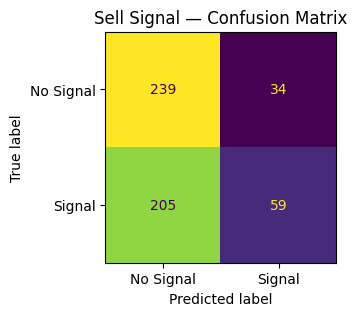

In [ ]:
# Evaluate Sell Model
y_prob_sell = evaluate_model(model_sell, X_te_sn, y_te_s, "Sell Signal")

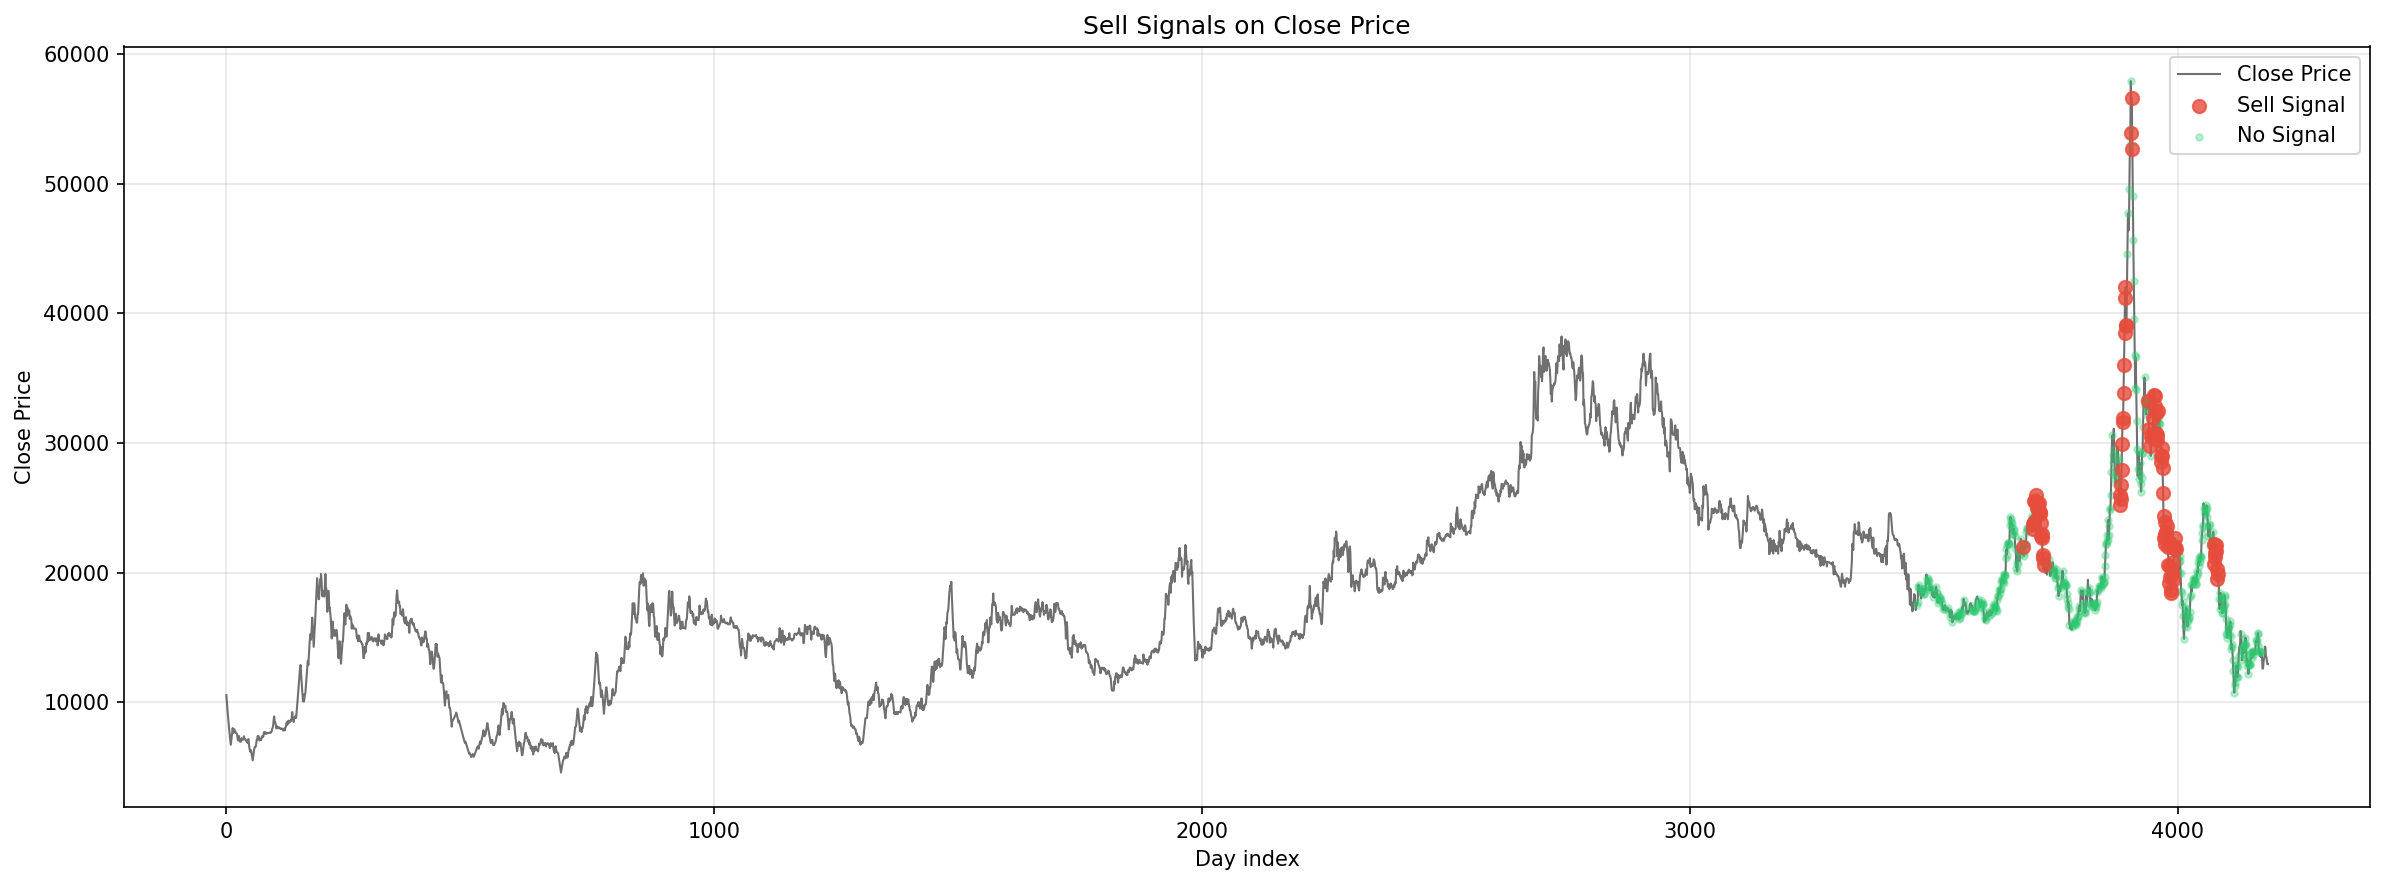

In [ ]:
# Plot Sell Signals
y_pred_sell = (y_prob_sell >= 0.5).astype(int)
test_indices_sell = idx_sell[-len(y_pred_sell):]
plot_signals_on_price(
    close,
    test_indices_sell,
    y_pred_sell,
    y_prob_sell,
    "Sell",
    WINDOW_SIZE,
    color_signal='#e74c3c',
    color_no='#2ecc71'
)

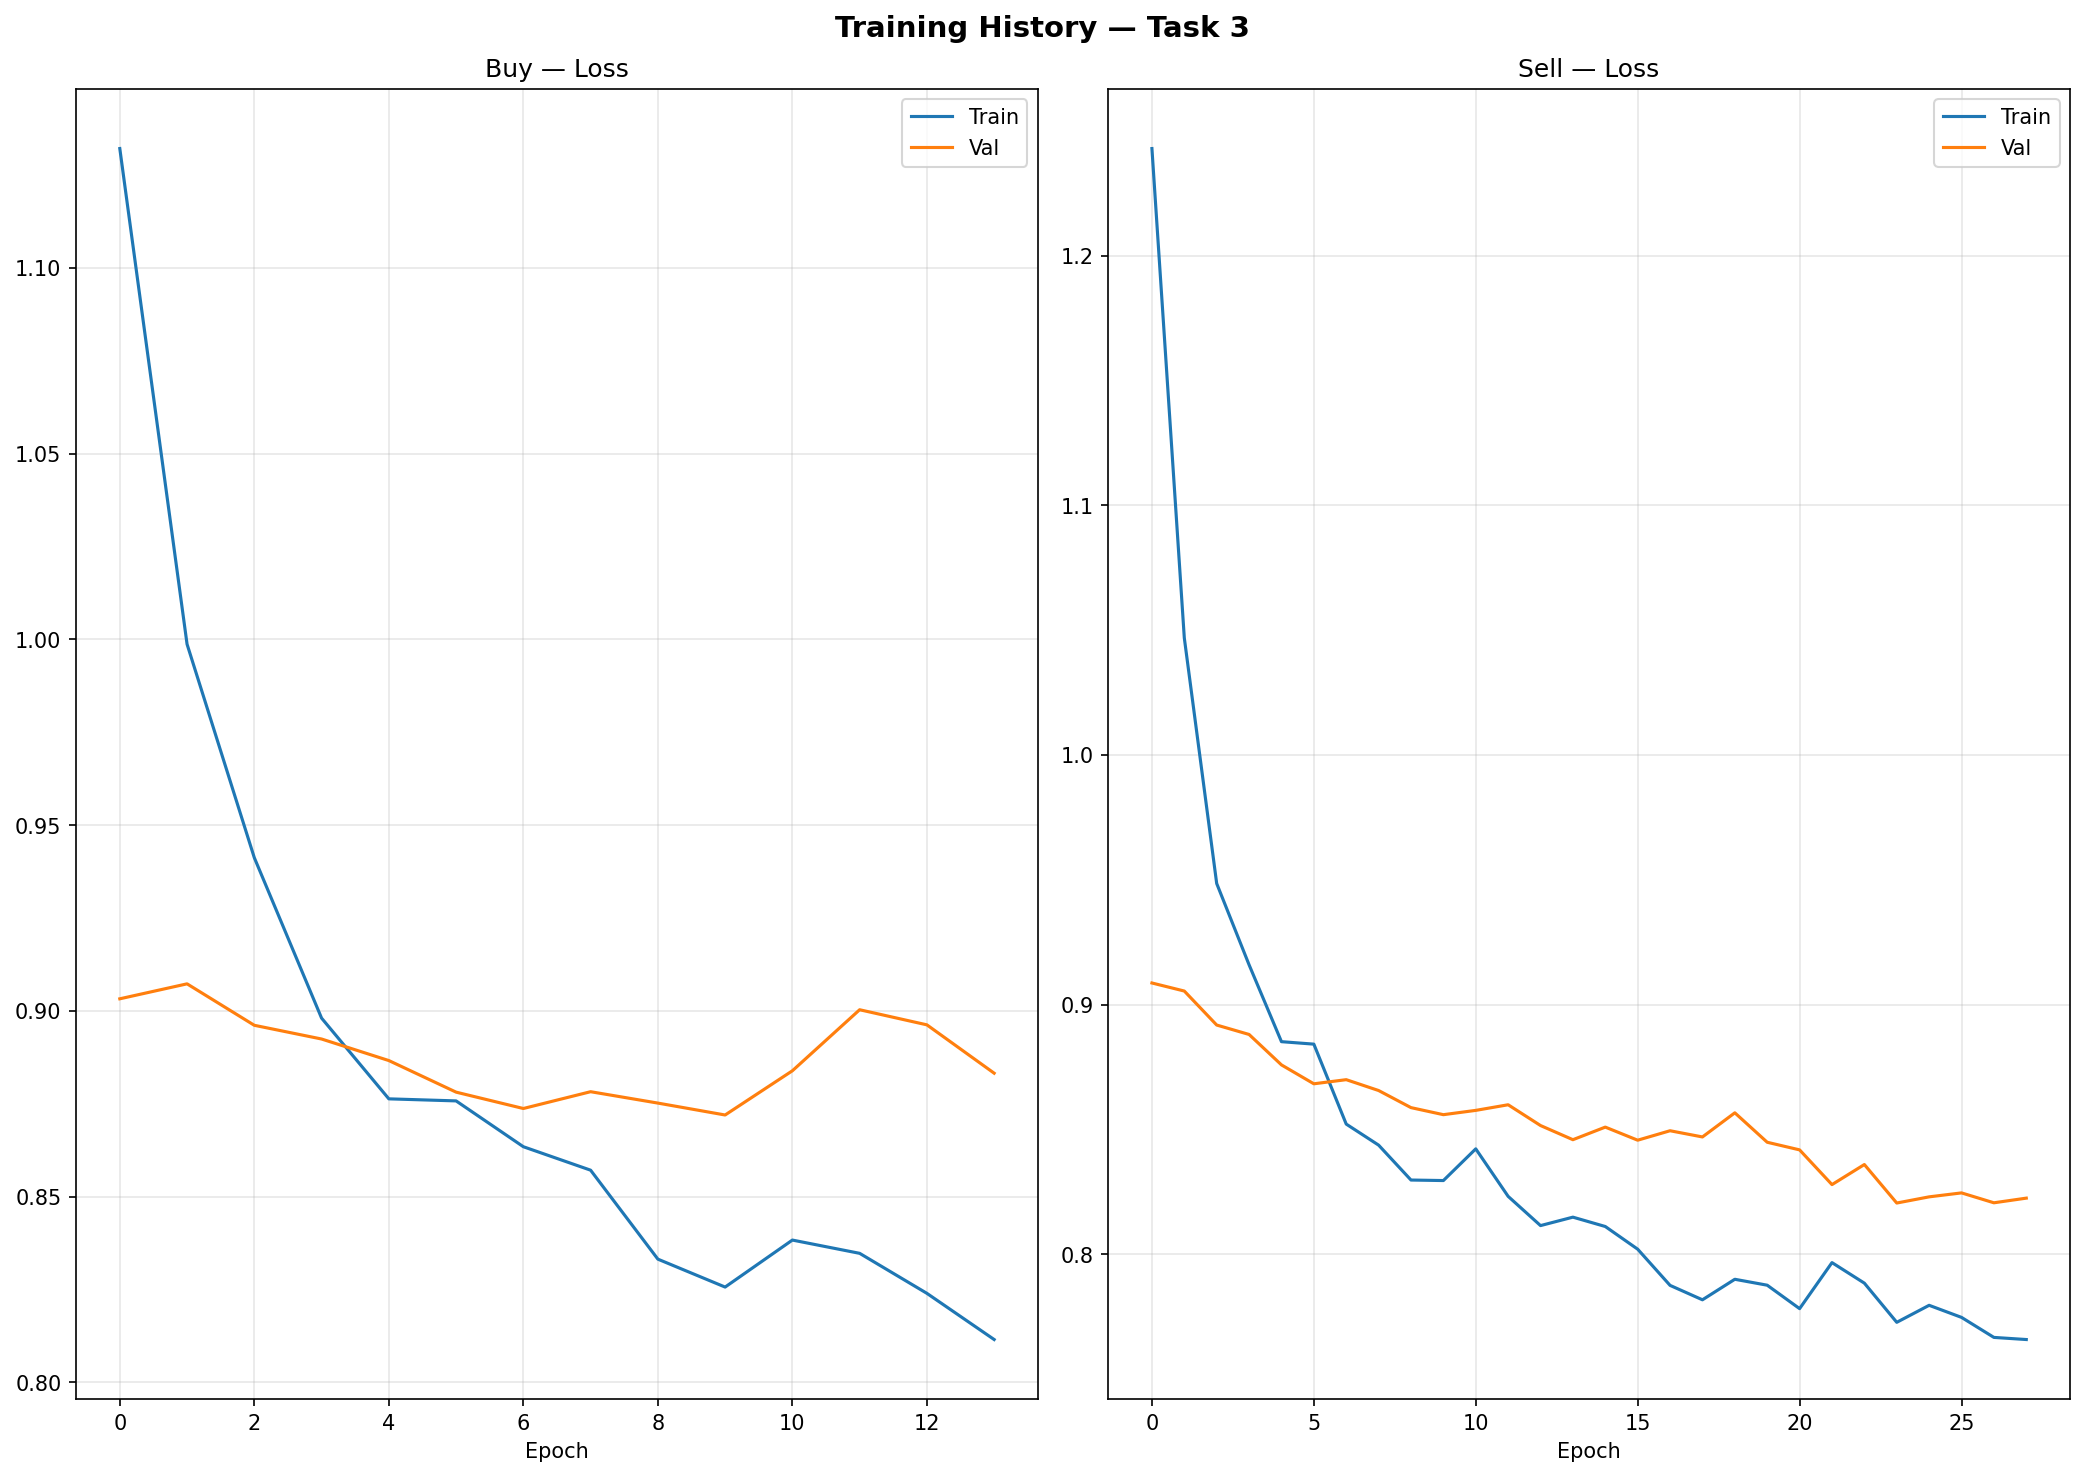

In [ ]:
# Training History Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 10), dpi=150)

for ax, hist, title in zip(axes.flatten(), [history_buy, history_sell], ['Buy — Loss', 'Sell — Loss']):
    metric = 'loss'
    ax.plot(hist.history[metric], label='Train')
    ax.plot(hist.history[f'val_{metric}'], label='Val')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — Task 3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()